# CIFAR-10

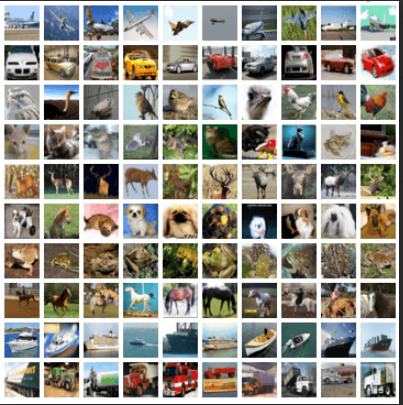


Éstas son las características generales de CIFAR-10:
* Se compone de 60.000 imágenes.
* Cada imagen es 32x32x3, en espacio RGB.
* Hay 50.000 imágenes de entrenamiento.
* Hay 10.000 imágenes de prueba.
* Hay 10 clases, donde cada una está representada por 6.000 imágenes.

Las clases son mutuamente excluyentes (es decir, una misma foto no puede pertenecer a más de una clase). Estas son las 10 clases de CIFAR-10:
* airplane (avión).
* automobile (automóvil).
* bird (ave).
* cat (gato).
* deer (venado).
* dog (perro).
* frog (rana).
* horse (caballo).
* ship (barco).
* truck (camión).

# Implementación en TensorFlow/Keras — CNN sobre CIFAR-10 (Clase 13)

**Módulo 07 — Fundamentos de Deep Learning.** Este notebook corresponde a la **Clase 13** y construye, en TensorFlow/Keras, la **misma red** convolucional que en la Clase 12 se armó en PyTorch sobre **CIFAR-10**: 60.000 imágenes en color de 32×32 píxeles en 10 clases, con la partición estándar de **50.000 imágenes de entrenamiento y 10.000 de test**.

La arquitectura es idéntica (3 bloques convolución + pooling, con 32, 64 y 128 filtros, seguidos de capas densas), pero el código luce muy distinto porque **Keras resuelve por dentro** buena parte de lo que en PyTorch había que escribir a mano: el bucle de entrenamiento, el cálculo de gradientes por lote, y la conversión de logits a probabilidades. Ese contraste — mismo modelo, dos formas de expresarlo — es justamente lo que vale la pena mirar en esta clase, y se retoma en la sección comparativa al final del notebook.

## 1. Librerías

| Import | Para qué |
|---|---|
| `tensorflow` | el framework completo |
| `tensorflow.keras.layers`, `.models` | capas (`Conv2D`, `Dense`, `MaxPool2D`) y el contenedor `Sequential` |
| `tensorflow.keras.utils.to_categorical` | codificar las etiquetas como one-hot |
| `matplotlib.pyplot` | visualización de imágenes y curvas de entrenamiento |

A diferencia de PyTorch, acá no hace falta `torchvision` ni un `DataLoader` aparte: Keras trae **CIFAR-10 empaquetado** directamente en `tf.keras.datasets`.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

## 2. Carga del dataset

`tf.keras.datasets.cifar10.load_data()` descarga (o reutiliza si ya está en caché) el dataset y lo devuelve **ya partido en train/test**, como arrays de NumPy. No hay que instanciar un `Dataset` ni un `DataLoader`, ni definir transformaciones todavía: eso llega después, a mano, con operaciones directas sobre los arrays.

In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

## 3. Verificación de shapes

`X_train` tiene shape `(50000, 32, 32, 3)` y `X_test` `(10000, 32, 32, 3)` — en Keras el orden de los ejes es `(cantidad, alto, ancho, canales)` (formato *channels-last*), al revés que en PyTorch, que usa `(canales, alto, ancho)` (*channels-first*). Es una diferencia de convención entre frameworks que hay que tener presente al portar arquitecturas de uno a otro.

`y_train` e `y_test` tienen shape `(50000, 1)` y `(10000, 1)`: un entero de clase (0-9) por imagen, todavía sin codificar.

In [ ]:
print("Train samples: ", X_train.shape, y_train.shape)
print("Test samples: ", X_test.shape, y_test.shape)

Train samples:  (50000, 32, 32, 3) (50000, 1)
Test samples:  (10000, 32, 32, 3) (10000, 1)


## 4. Nombres de las clases

Lista ordenada de las 10 categorías, en el mismo orden que los índices 0-9 de `y_train`/`y_test`.

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

## 5. Vista previa del dataset

Muestra las primeras 25 imágenes de `X_train` en una grilla de 5×5, con su etiqueta real como título, para confirmar visualmente que los datos están bien cargados antes de tocar nada.

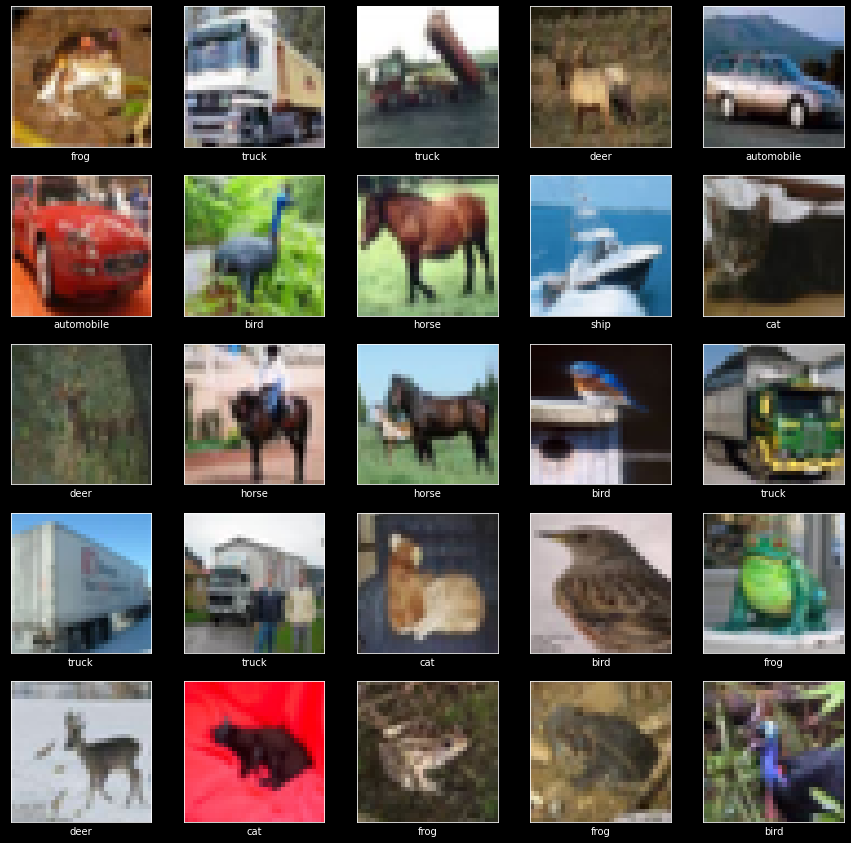

In [ ]:
plt.figure(figsize=(15,15))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.show()

## 6. Normalización y codificación one-hot

Dos transformaciones, y las dos son el punto de comparación más directo con el notebook de PyTorch (Clase 12):

- **Normalización: `X_train / 255`.** Los píxeles llegan en el rango 0-255; dividir por 255 los deja en **[0, 1]**. En PyTorch, en cambio, se usó `Normalize((0.5,)*3, (0.5,)*3)`, que deja el rango en **[-1, 1]** (media 0). Ambos enfoques son válidos y ambos son consistentes entre train y test — lo que cambia es la escala de entrada a la red, y por eso no tiene sentido comparar los valores de pérdida entre los dos notebooks número contra número.
- **One-hot con `to_categorical(y_train, 10)`.** Acá está la diferencia real de fondo, no solo de escala: `y_train` pasa de shape `(50000, 1)` con valores enteros (0 a 9) a shape `(50000, 10)` con un vector de ceros y un solo 1 en la posición de la clase correcta (por ejemplo, clase 4 queda `[0,0,0,0,1,0,0,0,0,0]`). **En PyTorch esto no se hace**: las etiquetas se dejan como enteros (`dtype=long`) porque `CrossEntropyLoss` las espera así y hace el equivalente del one-hot internamente. Acá el one-hot es necesario porque se va a usar `categorical_crossentropy`, que sí espera esa forma explícita en `y_true`.

In [ ]:
X_train2 = X_train / 255
X_test2 = X_test / 255

print("y_train shape %s and value %s" % (y_train.shape, y_train))
print("y_test shape %s and value %s" % (y_test.shape, y_test))

y_train2 = to_categorical(y_train, 10) #[0, 0, 0, 0, 1, 0, 0, 0 ,0, 0]

y_test2 = to_categorical(y_test, 10)

print("y_train shape %s and value %s" % (y_train2.shape, y_train2))
print("y_test shape %s and value %s" % (y_test2.shape, y_test2))

y_train shape (50000, 1) and value [[6]
 [9]
 [9]
 ...
 [9]
 [1]
 [1]]
y_test shape (10000, 1) and value [[3]
 [8]
 [8]
 ...
 [5]
 [1]
 [7]]
y_train shape (50000, 10) and value [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]
y_test shape (10000, 10) and value [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]]


## 7. Arquitectura de la red

La misma red del notebook de PyTorch, expresada con la API `Sequential` de Keras:

| Bloque | Capa Keras | Equivalente PyTorch | Shape de salida |
|---|---|---|---|
| Entrada | `input_shape=(32,32,3)` | tensor `(3,32,32)` | `(32,32,3)` |
| 1 | `Conv2D(32,(3,3),activation='relu',padding='same')` | `Conv2d(3→32,k=3,padding=1)` + `relu` | `(32,32,32)` |
| | `MaxPool2D(2,2)` | `MaxPool2d(2,2)` | `(16,16,32)` |
| 2 | `Conv2D(64,(3,3),activation='relu',padding='same')` | `Conv2d(32→64,...)` | `(16,16,64)` |
| | `MaxPool2D(2,2)` | | `(8,8,64)` |
| 3 | `Conv2D(128,(3,3),activation='relu',padding='same')` | `Conv2d(64→128,...)` | `(8,8,128)` |
| | `MaxPool2D(2,2)` | | `(4,4,128)` |
| Flatten | `Flatten()` | `x.view(-1, 128*4*4)` | `(2048,)` |
| FC1 | `Dense(512, activation='relu')` | `Linear(2048→512)` + relu | `(512,)` |
| FC2 | `Dense(256, activation='relu')` | `Linear(512→256)` + relu | `(256,)` |
| Salida | `Dense(10, activation='softmax')` | `Linear(256→10)` sin activación | `(10,)` |

Dos diferencias de sintaxis a notar:

- **`padding='same'`** en Keras equivale al `padding=1` explícito de PyTorch para un kernel 3×3: en ambos casos la convolución conserva el alto y el ancho, y es el `MaxPool2D`/`MaxPool2d` el que reduce el tamaño en cada bloque (32→16→8→4, igual que en PyTorch).
- **La capa de salida lleva `activation='softmax'`**, a diferencia de PyTorch donde `fc3` no tenía activación. Es la contraparte exacta del punto anterior sobre las etiquetas: como acá se usa `categorical_crossentropy` (que espera **probabilidades**, no logits), el softmax tiene que estar en el modelo. En PyTorch el softmax queda **incluido dentro de `CrossEntropyLoss`**, por eso la red no lo lleva explícito.

In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
model.add(layers.MaxPool2D(2, 2))


model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPool2D(2, 2))


model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPool2D(2, 2))

model.add(layers.Flatten())

model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

c:\Users\MSI\anaconda3\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 8. Resumen del modelo

`model.summary()` es el equivalente de `torchsummary.summary()` en PyTorch: lista cada capa con su shape de salida y su cantidad de parámetros. El resultado coincide con la tabla de la sección anterior y con el conteo total de PyTorch: **1.276.234 parámetros**, con la primera capa densa (`Dense(512)`, 1.049.088 parámetros) concentrando la mayoría, igual que en la versión de PyTorch — es literalmente la misma arquitectura, así que el conteo de parámetros da idéntico.

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,276,234 (4.87 MB)

 Trainable params: 1,276,234 (4.87 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Compilación: pérdida, optimizador y métrica

`model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])` es la contraparte de la celda de PyTorch que definía `criterion` y `optimizer` por separado, pero acá:

- **Optimizador `'adam'`**, no SGD con momentum como en PyTorch (Clase 12) — otra diferencia entre ambos notebooks a tener en cuenta al comparar resultados.
- **`categorical_crossentropy`** espera las etiquetas ya en one-hot (de ahí el `to_categorical` de la celda 6) — el equivalente de `CrossEntropyLoss`, pero sin el `log_softmax` interno porque la red ya devuelve probabilidades (softmax en la última capa).
- **`metrics=['accuracy']`** hace que Keras calcule y reporte la exactitud automáticamente durante el entrenamiento, algo que en PyTorch había que programar a mano después de entrenar.

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## 10. Entrenamiento

`model.fit(X_train2, y_train2, batch_size=8, epochs=2, validation_data=(X_test2, y_test2))` reemplaza en una sola línea todo el bucle manual de PyTorch (`zero_grad → forward → loss → backward → step`, repetido por lote y por época). Keras hace internamente los mismos pasos, pero los esconde detrás de esta llamada.

Parámetros, para que sean comparables con el notebook de PyTorch:

- **`batch_size=8`**: el mismo tamaño de lote que en PyTorch, por lo que también da 6.250 lotes por época sobre las 50.000 imágenes de train.
- **`epochs=2`**: mismo número de épocas que en PyTorch, para que la comparación entre frameworks sea lo más pareja posible.
- **`validation_data=(X_test2, y_test2)`**: hace que, al final de cada época, Keras evalúe también sobre el set de test y reporte `val_accuracy`/`val_loss` — una comodidad que en PyTorch requeriría escribir el bloque de evaluación aparte y llamarlo manualmente después de cada época.

In [ ]:
history = model.fit(X_train2, y_train2, batch_size=8, epochs=2, validation_data=(X_test2, y_test2))

Epoch 1/2
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 113s 18ms/step - accuracy: 0.3897 - loss: 1.6429 - val_accuracy: 0.5900 - val_loss: 1.1549
Epoch 2/2
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 112s 18ms/step - accuracy: 0.6339 - loss: 1.0374 - val_accuracy: 0.6303 - val_loss: 1.0537


## 11. Evaluación final

`model.evaluate(X_test2, y_test2)` recorre todo el test set y devuelve la pérdida y la exactitud finales, equivalente a la celda de PyTorch que contaba aciertos a mano con `torch.no_grad()` y `torch.max(outputs.data, 1)`.

In [ ]:
test_loss, test_acc = model.evaluate(X_test2, y_test2)
print(f'Test accuracy: {test_acc * 100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6298 - loss: 1.0500
Test accuracy: 63.03%


## 12. Curvas de exactitud

Grafica `accuracy` (train) y `val_accuracy` (test) por época, tomadas del objeto `history` que devuelve `model.fit`. Es el equivalente Keras del gráfico de pérdida que se arma a mano en PyTorch acumulando `epoch_losses` en una lista durante el bucle de entrenamiento.

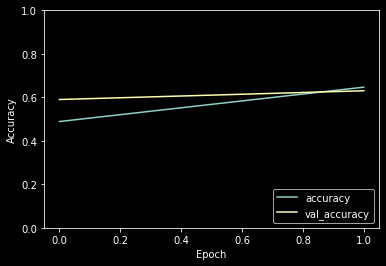

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc = 'lower right')
plt.show()

## Cierre: resultados y comparación PyTorch vs Keras

### Resultados reales (outputs guardados en este notebook)

- **Época 1**: `accuracy` 38,97 %, `val_accuracy` 59,00 %.
- **Época 2**: `accuracy` 63,39 %, `val_accuracy` 63,03 %.
- **Exactitud de test final** (`model.evaluate`): **63,03 %**.

(Este notebook no reporta exactitud por clase — a diferencia del de PyTorch, acá no se agregó esa celda.)

### Lectura crítica

63,03% es mejor que el 58,85% de la versión en PyTorch, y las causas más probables **no** son la arquitectura (es la misma) sino las diferencias de configuración señaladas a lo largo del notebook: **Adam** en vez de SGD con momentum converge más rápido en pocas épocas, y eso alcanza a notarse incluso en apenas 2 épocas. De todos modos, sigue siendo un resultado bajo para CIFAR-10 por las mismas razones que en PyTorch: **solo 2 épocas** (la exactitud de validación todavía venía subiendo), sin `BatchNormalization`, sin `Dropout` y sin *data augmentation*.

Mejoras esperables, en el mismo orden que en la versión de PyTorch: más épocas, `BatchNormalization` después de cada `Conv2D`, `Dropout` antes de las capas densas, augmentation (flips, recortes) sobre las imágenes de entrenamiento, y un *learning rate scheduler* o `ReduceLROnPlateau`.

### PyTorch vs Keras, para la misma red

| Aspecto | PyTorch (Clase 12) | Keras (Clase 13) |
|---|---|---|
| Formato de imagen | `(canales, alto, ancho)` | `(alto, ancho, canales)` |
| Normalización | `Normalize` → rango `[-1, 1]` | `/255` → rango `[0, 1]` |
| Etiquetas | enteros de clase (`dtype=long`) | one-hot (`to_categorical`) |
| Última capa | `Linear` sin activación (logits) | `Dense` con `softmax` (probabilidades) |
| Función de pérdida | `CrossEntropyLoss` (incluye softmax) | `categorical_crossentropy` (espera probabilidades) |
| Optimizador usado acá | `SGD(lr=0.001, momentum=0.9)` | `adam` (parámetros por defecto) |
| Bucle de entrenamiento | escrito a mano (`zero_grad/forward/backward/step`) | `model.fit(...)` en una línea |
| Evaluación por época sobre test | hay que programarla aparte | automática con `validation_data` |
| Exactitud de test | 58,85 % | 63,03 % |

La diferencia de exactitud entre ambos notebooks se explica más por el optimizador (Adam vs SGD) que por el framework en sí: la arquitectura, el número de parámetros (1.276.234 en los dos casos) y el número de épocas son idénticos.